In [1]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import inferagni as ia
import pandas as pd
from cmcrameri import cm
import os
from copy import deepcopy


from inferagni.plot import truth_color, samples_color, DPI
from inferagni.util import varprops

/home/harrison/miniforge3/envs/proteus/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/harrison/.var/app/com.visualstudio.code/config', but the default location, /home/harrison/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [2]:
# %config InlineBackend.figure_format = 'retina'

In [3]:
cases = {"Fbol+Comp":None, "Fbol":None, "Comp":None, "Neither":None}

outdir = "output/"
planet = "pi_Men_c"
end_frac = 0.01

for k in cases.keys():
    outdir_planet = os.path.join(outdir,f"{planet}({k})")
    print(outdir_planet)

    samps = pd.read_csv(os.path.join(outdir_planet,"result.csv"),skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(os.path.join(outdir_planet,"truth.csv" ),skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # sort samples into best-fit order
    r_phot_obs = truth.loc[truth["key"]=="r_phot"]["value"].iloc[0]
    mask = np.argsort(np.abs(samps["r_phot"].values - r_phot_obs))[::-1]
    samps = samps.iloc[mask]

    # get last samples from samps
    nsamp = int(len(samps)*end_frac)
    print(f"Number of samples: {len(samps)}")
    samps = samps.iloc[-nsamp:]

    cases[k] = {"samps":samps, "truth":truth}

    print(truth.keys())
    print(samps.keys())
    print("")

output/pi_Men_c(Fbol+Comp)
Number of samples: 19200
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2S', 'Kzz_max', 'r_phot', 'log_vmr_H2O',
       'log_vmr_H2', 'μ_phot', 't_surf', 'log_vmr_CO2'],
      dtype='str')

output/pi_Men_c(Fbol)
Number of samples: 35200
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_H2S', 'μ_phot', 'log_vmr_H2', 't_surf', 'r_phot',
       'log_vmr_CO2', 'Kzz_max', 'log_vmr_H2O'],
      dtype='str')

output/pi_Men_c(Comp)
Number of samples: 24000
Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_vmr_CO2', 'log_vmr_H2S', 'log_vmr_H2', 'log_vmr_H2O',
       'r_phot', 't_surf', 'Kzz_max', 'μ_phot'],
      dtype='str')

output/pi_Men_c(Neither)
Number 

Fbol+Comp
    Reds
    Nsamp: 192
    frac_atm        : 0.0265531 (0.0211952 , 0.0391751)
    logZ            : 0.288509 (0.189369 , 0.33297)
Fbol
    Greens
    Nsamp: 352
    frac_atm        : 0.0026257 (0.00171608 , 0.0139904)
    logZ            : -0.261322 (0.963691 , 0.510969)
Comp
    Blues
    Nsamp: 240
    frac_atm        : 0.0391199 (0.0332354 , 0.0480501)
    logZ            : 0.404756 (0.286329 , 0.388706)
Neither
    Greys
    Nsamp: 352
    frac_atm        : 0.00395319 (0.00272323 , 0.022569)
    logZ            : -0.454822 (0.944819 , 0.765137)


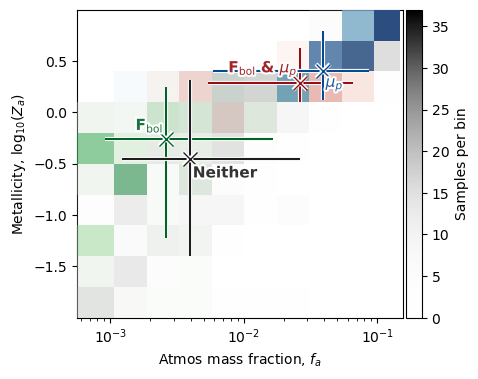

In [5]:
fig,ax = plt.subplots(1,1, figsize=(5,4))

xkey = "frac_atm"
ykey = "logZ" # μ_phot

nbins = 10
scat_val = 0.3

plot_types = ["hist2d"]

cmap_dict = {
    "Fbol+Comp": "Reds",
    "Fbol":      "Greens",
    "Comp":      "Blues",
    "Neither":   "Greys"
}

hist = {}
counts_max = 1
xmin, xmax = np.inf, -np.inf
ymin, ymax = np.inf, -np.inf
for k in cases.keys():

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    if xkey.startswith("log_vmr"):
        x = np.clip(x, np.percentile(x, 1), 1)
    if ykey.startswith("log_vmr"):
        y = np.clip(y, np.percentile(y, 1), 1)

    if varprops[xkey].log:
        x = np.log10(x)
    if varprops[ykey].log:
        y = np.log10(y)

    xmin = min(xmin, np.amin(x))
    xmax = max(xmax, np.amax(x))
    ymin = min(ymin, np.amin(y))
    ymax = max(ymax, np.amax(y))

max_counts = 2
for k in cases.keys():

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale

    if varprops[xkey].log:
        x = np.log10(x)
    if varprops[ykey].log:
        y = np.log10(y)

    counts, xbins, ybins = np.histogram2d(x,y, bins=nbins, range=[[xmin,xmax],[ymin,ymax]])

    if varprops[xkey].log:
        xbins = 10**xbins
    if varprops[ykey].log:
        ybins = 10**ybins

    # counts *= 100/len(counts.flatten())
    max_counts = max(max_counts, np.amax(counts))

    hist[k] = (counts.T, xbins, ybins)
norm = mpl.colors.Normalize(vmin=0, vmax=max_counts)


zorder = 20
for k in cases.keys():
    print(k)
    print("    "+cmap_dict[k])

    cmap_orig = deepcopy(plt.get_cmap(cmap_dict[k]))
    cmap = cmap_orig(np.arange(cmap_orig.N))
    cmap[:,-1] = np.linspace(0, 1, cmap_orig.N)
    cmap = mpl.colors.ListedColormap(cmap)

    x = cases[k]["samps"][xkey] * varprops[xkey].scale
    y = cases[k]["samps"][ykey] * varprops[ykey].scale
    print(f"    Nsamp: {len(x)}")

    counts = hist[k][0]
    xbins = hist[k][1]
    ybins = hist[k][2]
    xbins_mid = (xbins[1:]+xbins[:-1])/2
    ybins_mid = (ybins[1:]+ybins[:-1])/2

    for i,plot_type in enumerate(plot_types):

        if plot_type=="scatter":
            ax.scatter(x,y, color=cmap(scat_val), s=3, edgecolors='none',
                       rasterized=True, zorder=zorder+i)

        elif plot_type == "hist2d":
            ax.pcolormesh(xbins_mid, ybins_mid, counts,
                                cmap=cmap, norm=norm, rasterized=True, zorder=zorder+i
                                )

        elif plot_type == "contourf":
            ax.contourf(xbins_mid, ybins_mid, counts, levels=np.shape(counts)[1],
                                cmap=cmap, norm=norm, zorder=zorder+i
                                )

        elif plot_type == "contour":
            ax.contour(xbins_mid, ybins_mid, counts, levels=np.shape(counts)[1],
                                cmap=cmap, norm=norm, zorder=zorder+i
                                )

        else:
            raise ValueError("Invalid plot type:", plot_type)

    _pe_text = [mpl.patheffects.Stroke(linewidth=3, foreground='w'), mpl.patheffects.Normal()]


    lbl = f"{k}"
    col = cmap(0.9)
    x0 = np.median(x)
    y0 = np.median(y)
    xerr = [[x0-np.percentile(x, 16)], [np.percentile(x, 84)-x0]]
    yerr = [[y0-np.percentile(y, 16)], [np.percentile(y, 84)-y0]]
    print(f"    {xkey:16s}: {x0:g} ({xerr[0][0]:g} , {xerr[1][0]:g})")
    print(f"    {ykey:16s}: {y0:g} ({yerr[0][0]:g} , {yerr[1][0]:g})")
    ax.errorbar([x0], [y0], xerr=xerr, yerr=yerr,
                color=col, alpha=1, path_effects=_pe_text,
                marker='x', markersize=10, label=lbl,zorder=50)

    if "Fbol" in lbl:
        offset = (-2,10)
        ha = 'right'
    else:
        offset = (2,-10)
        ha = 'left'
    lbl = lbl.replace("Fbol",r"F$_{\text{bol}}$")
    lbl = lbl.replace("Comp",r"$\mu_p$")
    lbl = lbl.replace("+"," & ")
    ax.annotate(lbl, (x0, y0), offset, color=col, weight='bold', ha=ha, va='center',
                textcoords='offset points',zorder=52, fontsize=11, path_effects=_pe_text)

if plot_type != ["scatter"]:
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, label="Samples per bin")

ax.set_ylabel(varprops[ykey].label)
ax.set_xlabel(varprops[xkey].label)
if varprops[xkey].log:
    ax.set_xscale("log")
if varprops[ykey].log:
    ax.set_yscale("log")

ax.set_xlim(np.amin(xbins), np.amax(xbins))
ax.set_ylim(np.amin(ybins), np.amax(ybins))

# ax.legend(ncols=2)
# ax.set_title(planet.replace("_"," "))

fig.savefig(os.path.join(outdir,"ia_Fbol.pdf"),  dpi=DPI, bbox_inches="tight")
plt.show()